<div style="border-left: 6px solid #00356B; padding-left: 15px; margin-bottom: 20px;">
  <h1 style="margin-bottom: 5px; color: #00356B"><strong>Final Project:</strong> Utility-Constrained Causal Serendipity Recommender System</h1>
  <span style="font-size: 1.2em; color: #444; font-weight: bold">S&DS 5350 | Social Algorithms</span>
  <br><br>
  <strong>Primary:</strong> Cailey Bobadilla (cjb239)
  <br>
  <strong>Partner :</strong> Brandon Tran (bat53)
  <br>
  <strong>Group:</strong> 9
</div>

---

*Mood for this part:*

<iframe data-testid="embed-iframe" style="border-radius:12px" src="https://open.spotify.com/embed/track/5TdrCQVt3l1uEz3pFdTgXC?utm_source=generator" width="40%" height="152" frameBorder="0" allowfullscreen="" allow="autoplay; clipboard-write; encrypted-media; fullscreen; picture-in-picture" loading="lazy"></iframe>

**Dataset:** Last.fm HetRec 2011

**AI Acknowledgement:**
    
Claude Sonnet 4.6 and Gemini 3.1 Pro were both used to help develop the outputted tables and visualizations in this notebook.

### Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Import all functions and constants from the pipeline library
from serendipity_pipeline import (
    # Constants
    DATA_DIR, ALPHA, TAU_R, EPSILON, WINSORIZE_EPSILON, N_SLOTS, N_FACTORS, 
    N_ITER, TOP_K_TAGS,
    # Functions
    load_data,
    build_matrices,
    fit_poisson_factorization,
    StandardLMF,
    CausalLMF,
    build_artist_categories,
    compute_dynamic_epsilon,
    build_std_slate,
    build_causal_slate,
    build_serendipity_slate,
)

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE = (10, 4)

### Data Loading and Exploration

##### Load raw Last.fm data and assign each artist a genre category

In [2]:
# Load raw Last.fm data
ua, artists, tags, uta, user2idx, item2idx, n_users, n_items = load_data(DATA_DIR)

# Assign each artist to a genre category
item_to_category = build_artist_categories(uta, item2idx, top_k=TOP_K_TAGS)

Loaded: 1892 users, 17632 artists, 92834 interactions
Categories (11): ['indie', 'female vocalists', 'rock', 'pop', 'other', 'electronic', '80s', 'alternative', 'dance', 'classic rock', 'alternative rock']


##### Preview interaction data and summarize listen-count distribution

In [3]:
# Preview the core interaction data
print('user_artists.dat (first 5 rows):')
display(ua[['userID', 'artistID', 'weight', 'u', 'i']].head())
 
# Summarize listen count distribution
print('\nListen-count summary (r_ui):')
display(ua['weight'].describe().rename('r_ui').to_frame())

user_artists.dat (first 5 rows):


,userID,artistID,weight,u,i
0,2,51,13883,0,45
1,2,52,11690,0,46
2,2,53,11351,0,47
3,2,54,10300,0,48
4,2,55,8983,0,49



Listen-count summary (r_ui):


,r_ui
count,92834.0000
mean,745.2439
std,3751.3221
min,1.0000
25%,107.0000
50%,260.0000
75%,614.0000
max,352698.0000


##### Plot listen-count distribution and artists-per-user histograms

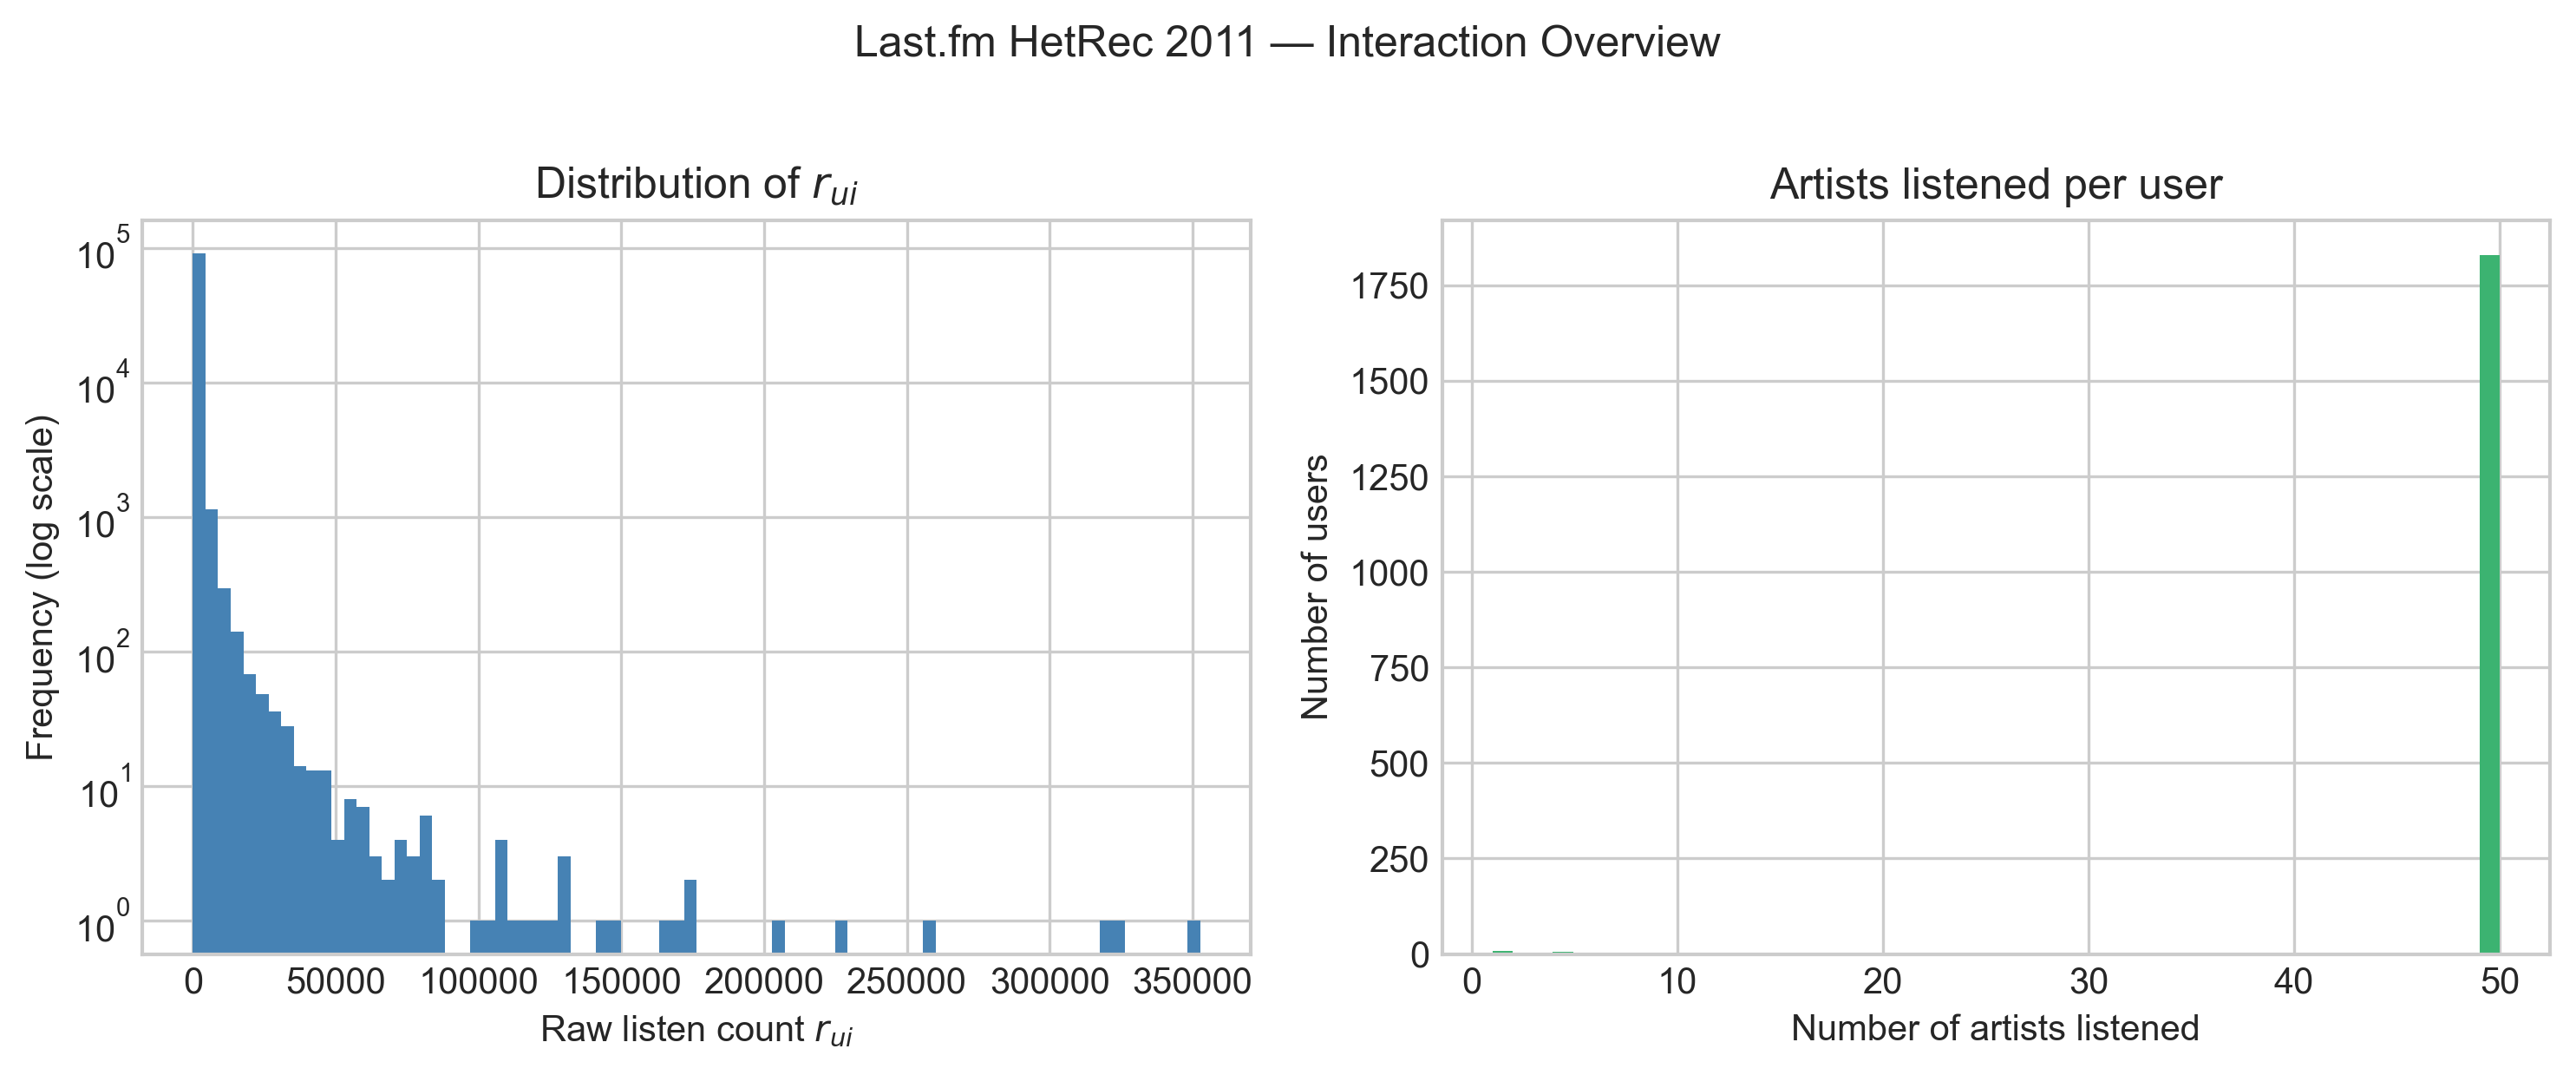

In [4]:
# Plot listen count distribution and artists per user histograms
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, dpi=300)
 
# Left: distribution of raw listen counts (log scale)
axes[0].hist(ua['weight'], bins=80, color='steelblue', edgecolor='none', 
             log=True)
axes[0].set_xlabel('Raw listen count $r_{ui}$')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Distribution of $r_{ui}$')
 
# Right: number of artists listened per user
user_counts = ua.groupby('userID')['artistID'].count()
axes[1].hist(user_counts, bins=50, color='mediumseagreen', edgecolor='none')
axes[1].set_xlabel('Number of artists listened')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Artists listened per user')
 
plt.suptitle('Last.fm HetRec 2011 — Interaction Overview', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

##### Top-50 most-listened artists globally

In [5]:
# Get Top-50 most-listened artists globally
top_artists = (
    ua.groupby('artistID')['weight']
    .sum()
    .reset_index()
    .merge(artists[['artistID', 'name']], on='artistID')
    .sort_values('weight', ascending=False)
    .head(50)
    .reset_index(drop=True)
)
top_artists.index += 1
top_artists.index.name = 'rank'
 
print('Top-50 most-listened artists (total listens across all users):')
display(top_artists[['name', 'weight']].rename(columns={'weight': 'total_listens'}))

Top-50 most-listened artists (total listens across all users):


,name,total_listens
rank,,
1,Britney Spears,2393140
2,Depeche Mode,1301308
3,Lady Gaga,1291387
4,Christina Aguilera,1058405
5,Paramore,963449
6,Madonna,921198
7,Rihanna,905423
8,Shakira,688529
9,The Beatles,662116


##### Global artist count per genre category

In [6]:
# Get global artist count per genre category
global_genre_counts = pd.Series(item_to_category).value_counts()

print("Global Artist Count per Genre:")
print(global_genre_counts)

Global Artist Count per Genre:
other               15320
rock                  409
pop                   351
electronic            323
indie                 292
female vocalists      239
alternative           203
80s                   152
dance                 133
classic rock          107
alternative rock      103
Name: count, dtype: int64


### Matrix Construction

In [7]:
# Build sparse matrices R and A from interaction data
# NOTE: C discarded here, rebuilt with final alpha/mode in hyperparameter cell
R, _, A = build_matrices(ua, n_users, n_items, mode='log')

Sparsity: 99.72%


### Hyperparameter Decisions

In [8]:
# Final hyperparameter configuration
ALPHA_FINAL = 40    # confidence log-scaling factor (Johnson's rec)
MODE_FINAL = 'log'  # log-scaling dampens heavy-listener dominance
N_ITER = 100        # overrides pipeline default (N_ITER=50)

_, C_final, _ = build_matrices(ua, n_users, n_items, alpha=ALPHA_FINAL, 
                               mode=MODE_FINAL)

Sparsity: 99.72%


### Stage 1: Exposure Modeling

##### Fit Hierarchical Poisson Factorization (HPF) to binary exposure matrix $A$

In [9]:
# Fit HPF to binary exposure matrix A
pf_model, a_hat = fit_poisson_factorization(A, n_factors=N_FACTORS)
 
# Save a_hat so Stage 2 can be re-run without repeating Stage 1
np.save('a_hat.npy', a_hat)

**********************************
Hierarchical Poisson Factorization
**********************************

Number of users: 1892
Number of items: 17632
Latent factors to use: 20

Initializing parameters...
Allocating Phi matrix...
Initializing optimization procedure...
Iteration 10 | train llk: -480209 | train rmse: 0.9493
Iteration 20 | train llk: -407018 | train rmse: 0.8947
Iteration 30 | train llk: -402045 | train rmse: 0.8904
Iteration 40 | train llk: -400244 | train rmse: 0.8891
Iteration 50 | train llk: -399468 | train rmse: 0.8885
Iteration 60 | train llk: -399032 | train rmse: 0.8882
Iteration 70 | train llk: -398661 | train rmse: 0.8879
Iteration 80 | train llk: -398480 | train rmse: 0.8878
Iteration 90 | train llk: -398378 | train rmse: 0.8878
Iteration 100 | train llk: -398245 | train rmse: 0.8877


Optimization finished
Final log-likelihood: -398245
Final RMSE: 0.8877
Minutes taken (optimization part): 0.1

a_hat range: [0.0000, 1.0000]
a_hat std: 0.0161


##### Plot exposure probability distribution and per-artist mean exposure

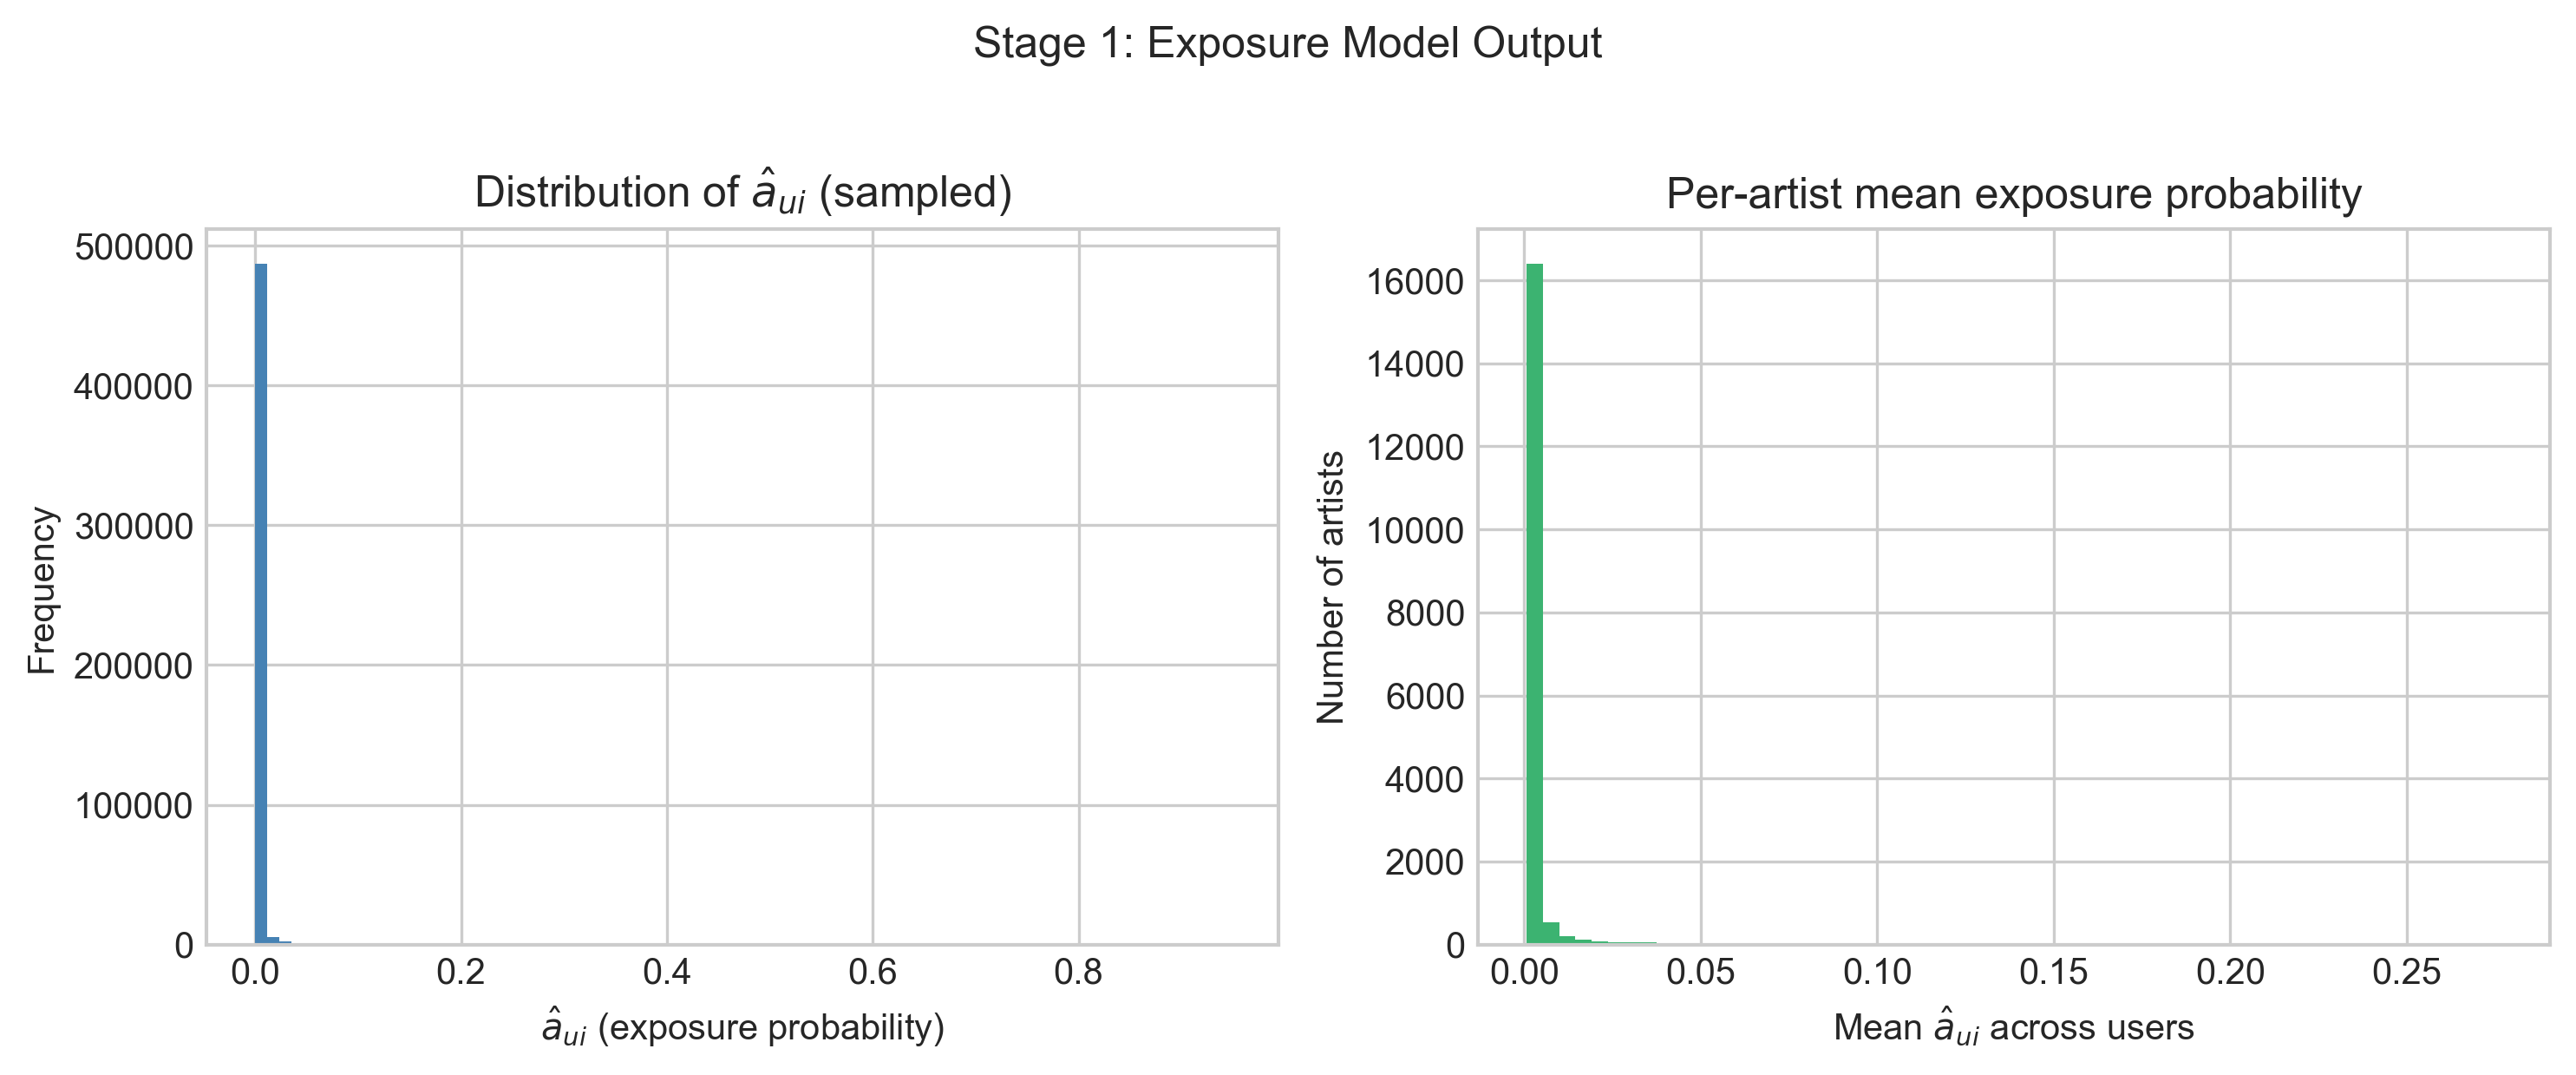

Mean a_hat: 0.0026
Median a_hat: 0.0008


In [10]:
# Plot exposure probability distribution and per artist mean exposure
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, dpi=300)
 
# Sample to keep plotting fast
rng = np.random.default_rng(0)
sample = rng.choice(a_hat.flatten(),
                    size=min(500_000, a_hat.size), replace=False)
 
# Left: overall a_hat (exposure probability) distribution
axes[0].hist(sample, bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('$\\hat{a}_{ui}$ (exposure probability)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of $\\hat{a}_{ui}$ (sampled)')
 
# Right: mean exposure per artist (popularity proxy)
item_exposure = a_hat.mean(axis=0)
axes[1].hist(item_exposure, bins=60, color='mediumseagreen', edgecolor='none')
axes[1].set_xlabel('Mean $\\hat{a}_{ui}$ across users')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Per-artist mean exposure probability')
 
plt.suptitle('Stage 1: Exposure Model Output', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
 
print(f'Mean a_hat: {a_hat.mean():.4f}')
print(f'Median a_hat: {np.median(a_hat):.4f}')

### Case Study: Target User 5

In [11]:
# Change TARGET_USER to any integer in [0, n_users) to inspect a different user
TARGET_USER = 5

##### Genre breakdown and weighted play saturation for User 5

In [12]:
# Filter using the mapped 'u' column
user_5_history = ua[ua['u'] == TARGET_USER].copy()

# Map the artist IDs to their genres
user_5_history['genre'] = user_5_history['artistID'].map(
    lambda x: item_to_category.get(item2idx.get(x, -1), 'Unknown')
)

# Count the occurrences of each genre
history_genre_counts = user_5_history['genre'].value_counts()

print(f"Genre Breakdown for User (u={TARGET_USER}):")
print(history_genre_counts)

# Calculate true saturation (weighted by play count)
weighted_saturation = user_5_history.groupby('genre')['weight'].sum()
print("\nTrue Genre Saturation (% of total plays):")
print(
    (weighted_saturation / weighted_saturation.sum() * 100)
    .sort_values(ascending=False)
)

Genre Breakdown for User (u=5):
genre
pop                 24
other               18
female vocalists     4
dance                2
rock                 2
Name: count, dtype: int64

True Genre Saturation (% of total plays):
genre
pop                74.7325
other              15.8901
female vocalists    4.2105
dance               2.7489
rock                2.4180
Name: weight, dtype: float64


##### Top-50 most listened artists for User 5

In [13]:
# Filter the interactions for mapped user u=5
user_5_interactions = ua[ua['u'] == TARGET_USER].copy()

# Rename weight to play_count for clarity (since weight = total plays)
user_5_interactions = user_5_interactions.rename(columns={'weight': 'play_count'})

# Merge with artists to get the names, sort by play count, and grab the top 50
user_5_top50 = (
    user_5_interactions
    .merge(artists[['artistID', 'name']], on='artistID', how='left')
    .sort_values('play_count', ascending=False)
    .head(50)[['name', 'play_count', 'artistID']] 
    .reset_index(drop=True)
)

# Add the genre column using the correct double-mapping logic
user_5_top50['genre'] = user_5_top50['artistID'].map(
    lambda x: item_to_category.get(item2idx.get(x, -1), 'Unknown')
)

# Clean up the dataframe to just show the relevant columns
user_5_top50 = user_5_top50[['name', 'play_count', 'genre']]

# Shift the index so the ranking starts at 1 instead of 0
user_5_top50.index += 1
user_5_top50.index.name = 'Rank'

# Display the results
print(f"Top 50 Most-Listened Artists for User (u={TARGET_USER}):")
display(user_5_top50)

Top 50 Most-Listened Artists for User (u=5):


,name,play_count,genre
Rank,,,
1,Rihanna,43864,pop
2,Britney Spears,11112,pop
3,Jordin Sparks,6266,pop
4,Lady Gaga,5846,pop
5,Kelly Clarkson,5379,pop
6,Mariah Carey,5188,other
7,Christina Aguilera,4201,pop
8,Ashlee Simpson,4059,pop
9,Leona Lewis,3251,female vocalists


### Stage 2: Outcome Modeling

##### Train Standard LMF baseline

In [15]:
# Train Standard LMF baseline (same hyperparameters, no confounder term)
print('Training Standard LMF Baseline')
baseline_lmf = StandardLMF(n_users, n_items, n_factors=N_FACTORS, n_iter=N_ITER,
                           lr=0.1, init_Theta=pf_model.Theta, 
                           init_Beta=pf_model.Beta)
baseline_lmf.fit(C_final)

Training Standard LMF Baseline
  Initializing with PF latent factors (Warm Start)
  Iter 5/100 | Log-likelihood: -46970347.34
  Iter 10/100 | Log-likelihood: -40054651.13
  Iter 15/100 | Log-likelihood: -41740962.83
  Iter 20/100 | Log-likelihood: -34803350.76
  Iter 25/100 | Log-likelihood: -38060468.14
  Iter 30/100 | Log-likelihood: -31870538.80
  Iter 35/100 | Log-likelihood: -34427277.48
  Iter 40/100 | Log-likelihood: -31241128.63
  Iter 45/100 | Log-likelihood: -32798288.08
  Iter 50/100 | Log-likelihood: -29607398.45
  Iter 55/100 | Log-likelihood: -31993974.31
  Iter 60/100 | Log-likelihood: -26714854.73
  Iter 65/100 | Log-likelihood: -31506114.80
  Iter 70/100 | Log-likelihood: -27404069.71
  Iter 75/100 | Log-likelihood: -29993988.95
  Iter 80/100 | Log-likelihood: -27345970.98
  Iter 85/100 | Log-likelihood: -29898898.67
  Iter 90/100 | Log-likelihood: -25753467.54
  Iter 95/100 | Log-likelihood: -31122970.14
  Iter 100/100 | Log-likelihood: -24251571.11


##### Train Causal LMF

In [14]:
# Train Causal LMF warm-started from HPF latent factors
lmf = CausalLMF(n_users, n_items, n_factors=N_FACTORS, n_iter=N_ITER, lr=0.1,
                init_Theta=pf_model.Theta, init_Beta=pf_model.Beta)
lmf.fit(C_final, a_hat)

  Initializing with PF latent factors (Warm Start)
  Iter 5/100 | Log-likelihood: -46842405.05
  Iter 10/100 | Log-likelihood: -40191322.62
  Iter 15/100 | Log-likelihood: -40211750.41
  Iter 20/100 | Log-likelihood: -33289729.29
  Iter 25/100 | Log-likelihood: -36262650.76
  Iter 30/100 | Log-likelihood: -30889272.28
  Iter 35/100 | Log-likelihood: -33490017.90
  Iter 40/100 | Log-likelihood: -29080177.91
  Iter 45/100 | Log-likelihood: -32974620.16
  Iter 50/100 | Log-likelihood: -27355327.76
  Iter 55/100 | Log-likelihood: -30937269.37
  Iter 60/100 | Log-likelihood: -27623735.87
  Iter 65/100 | Log-likelihood: -30583197.33
  Iter 70/100 | Log-likelihood: -26219183.08
  Iter 75/100 | Log-likelihood: -30282177.24
  Iter 80/100 | Log-likelihood: -26101108.30
  Iter 85/100 | Log-likelihood: -31094823.25
  Iter 90/100 | Log-likelihood: -27681934.73
  Iter 95/100 | Log-likelihood: -30029363.29
  Iter 100/100 | Log-likelihood: -27622875.94


##### Build Standard LMF slate

In [16]:
# Build Standard LMF slate (ranked by confounded preference score)
std_slate = build_std_slate(u=TARGET_USER, model=baseline_lmf, a_hat=a_hat, A=A,
                            item_to_category=item_to_category, artists=artists, 
                            item2idx=item2idx)

print('Standard LMF:')
display(std_slate)

Standard LMF:


,artist,category,pref_score,exposure_prob
rank,,,,
1,Maxwell,other,72.7736,0.7526
2,Bob Marley,other,33.5737,0.8028
3,James Blunt,pop,25.4255,0.0226
4,Amerie,other,24.5865,0.0012
5,50 Cent,other,24.2613,0.0008
6,Sandy Leah,other,21.8390,0.0011
7,Jessica Simpson,pop,21.2321,0.0005
8,Usher,other,20.5028,0.0046
9,John Legend,other,20.3304,0.0011


##### Build Causal LMF slate

In [17]:
# Build Causal LMF slate (ranked by unconfounded preference score)
causal_lmf_only_df = build_causal_slate(u=TARGET_USER, model=lmf, a_hat=a_hat, 
                                        A=A, item_to_category=item_to_category, 
                                        artists=artists, item2idx=item2idx)

print('Causal LMF:')
display(causal_lmf_only_df)

Causal LMF:


,artist,category,pref_score,exposure_prob
rank,,,,
1,Keane,alternative,43.9542,0.0201
2,James Blunt,pop,31.1082,0.0226
3,Céline Dion,female vocalists,28.2859,0.3952
4,Ke$ha,pop,23.8611,0.0025
5,Shakira,pop,23.8044,0.0060
6,Michael Jackson,pop,23.7586,0.0018
7,Miley Cyrus,pop,21.6738,0.0006
8,Demi Lovato,pop,21.3733,0.0012
9,Coldplay,alternative,19.6955,0.0004


### Stage 3: Serendipity Scoring and Slate Assembly

#### Slate Assembly

##### Build Causal LMF + Serendipity slate

In [18]:
# Build Causal LMF + Serendipity slate (ranked by S_ui)
seren_no_util = build_serendipity_slate(u=TARGET_USER, model=lmf, a_hat=a_hat, 
                                        A=A, item_to_category=item_to_category,
                                        artists=artists, item2idx=item2idx)

print('Causal LMF + Serendipity:')
display(seren_no_util)

Causal LMF + Serendipity:


,artist,category,S_ui,pref_score,exposure_prob
rank,,,,,
1,Timbaland,other,51801.0859,18.5178,0.0004
2,Coldplay,alternative,49822.9375,19.6955,0.0004
3,James Morrison,other,40217.4336,14.9425,0.0004
4,Nickelback,rock,38618.1055,13.7679,0.0004
5,Miley Cyrus,pop,35284.1289,21.6738,0.0006
6,Duffy,other,33704.1484,13.3236,0.0004
7,Glee Cast,other,30643.9805,15.8417,0.0005
8,Depeche Mode,electronic,29392.4590,11.6191,0.0004
9,Björk,electronic,28987.9336,10.9605,0.0004


##### Plot preference scores and exposure probabilities across all three slates

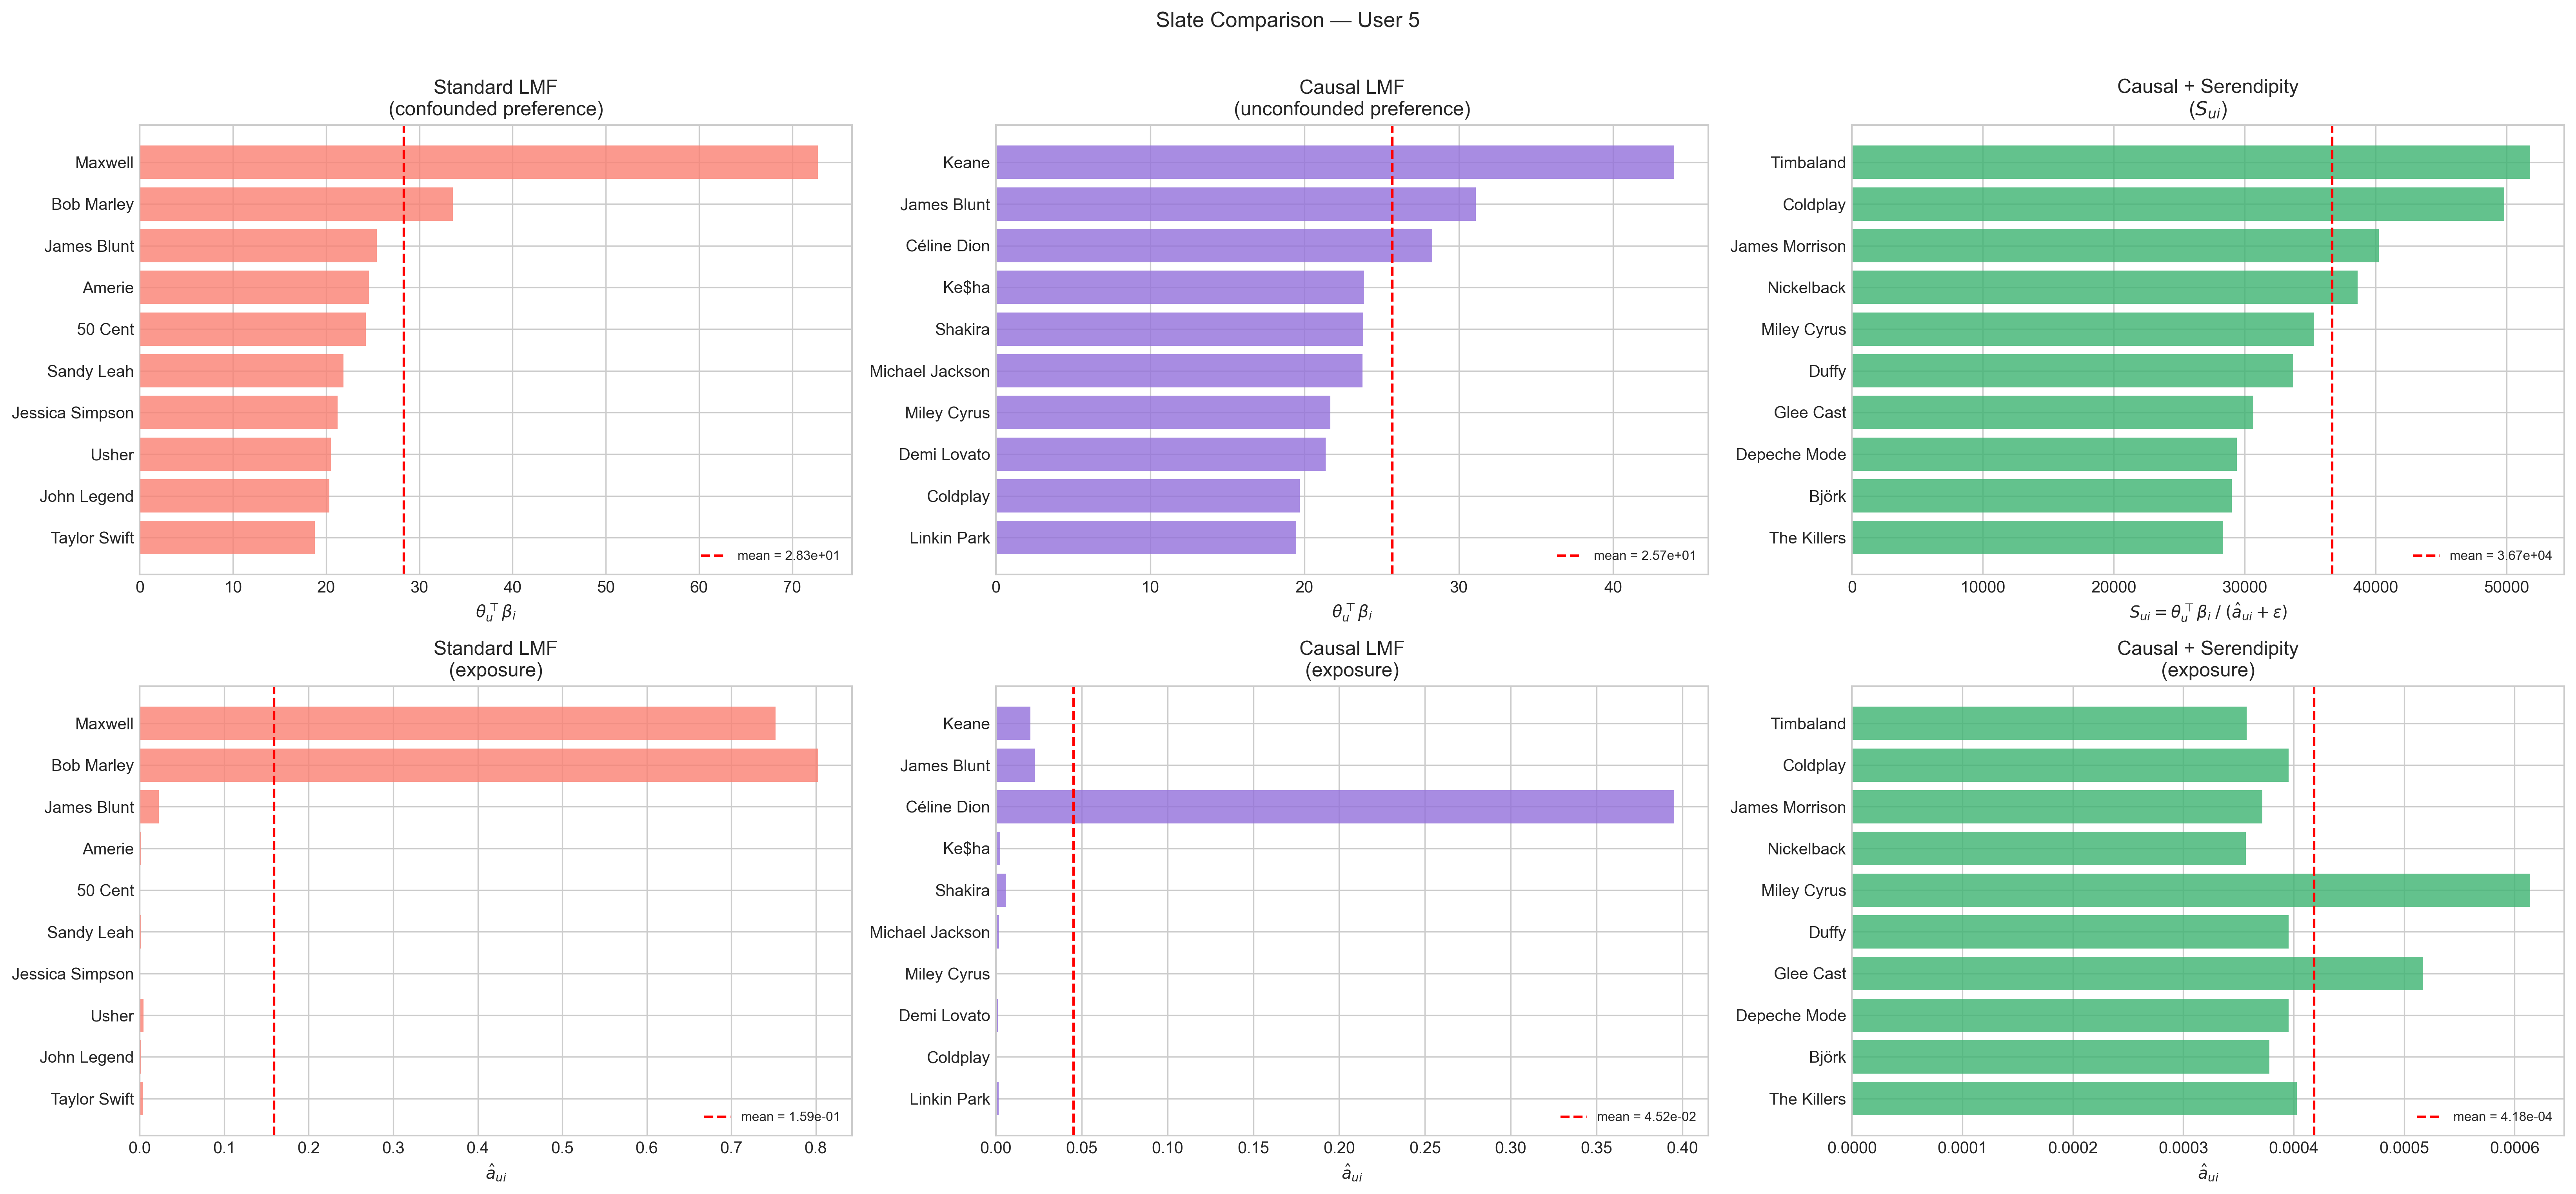

In [19]:
# Plot preference scores and exposure probabilities across all three slates
fig, axes = plt.subplots(2, 3, figsize=(22, 10), dpi=300)

# Helper to make a horizontal bar chart
def barh_chart(ax, df, score_col, color, title, xlabel):
    vals = df[score_col].values
    labels = df['artist'].values
    ax.barh(labels, vals, color=color, alpha=0.8)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    mean_v = vals.mean()
    ax.axvline(mean_v, color='red', linestyle='--', label=f'mean = {mean_v:.2e}')
    ax.legend(loc='lower right', fontsize=8)

# Row 1: Preference scores
barh_chart(axes[0,0], std_slate, 'pref_score', 'salmon',
           'Standard LMF\n(confounded preference)', 
           '$\\theta_u^\\top \\beta_i$')
barh_chart(axes[0,1], causal_lmf_only_df, 'pref_score', 'mediumpurple',
           'Causal LMF\n(unconfounded preference)', 
           '$\\theta_u^\\top \\beta_i$')
barh_chart(axes[0,2], seren_no_util, 'S_ui', 'mediumseagreen',
           'Causal + Serendipity\n($S_{ui}$)',
           '$S_{ui} = \\theta_u^\\top \\beta_i \\;/\\; (\\hat{a}_{ui}+\\epsilon)$')

# Row 2: Exposure probabilities
barh_chart(axes[1,0], std_slate, 'exposure_prob', 'salmon',
           'Standard LMF\n(exposure)', '$\\hat{a}_{ui}$')
barh_chart(axes[1,1], causal_lmf_only_df, 'exposure_prob', 'mediumpurple',
           'Causal LMF\n(exposure)', '$\\hat{a}_{ui}$')
barh_chart(axes[1,2], seren_no_util, 'exposure_prob', 'mediumseagreen',
           'Causal + Serendipity\n(exposure)', '$\\hat{a}_{ui}$')

plt.suptitle(f'Slate Comparison — User {TARGET_USER}',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Winsorization

In [20]:
# Define configuration of winsorization scatter
SCATTER_USERS = 100   # number of users to sample
SCATTER_SAMPLE = 150  # unobserved items to sample per user
rng_sc = np.random.default_rng(7)

# Compute both winsorization floors once from the full a_hat matrix
fixed_eps = WINSORIZE_EPSILON  # hard 0.01 floor
dynamic_eps = compute_dynamic_epsilon(a_hat, percentile=5)  # data-driven floor

print(f'WINSORIZE_EPSILON (fixed floor): {fixed_eps}')
print(f'Dynamic epsilon (5th percentile): {dynamic_eps:.6f}')


Dynamic epsilon (p5 of non-zero exposures): 0.000326
WINSORIZE_EPSILON (fixed floor): 0.01
Dynamic epsilon (5th percentile): 0.000326


##### Spotlight artists chosen to illustrate three diagnostic cases

In [21]:
# Spotlight artists chosen to illustrate three diagnostic cases
# - anomaly: Coldplay — near-zero exposure inflates S_ui before winsorization
# - popular: Rihanna — high exposure moderates S_ui despite strong preference
# - niche: Bjork — low exposure + moderate preference, stable under dynamic floor
# NOTE: Names must match the artists dataframe exactly (case-sensitive)
SPOTLIGHT = {
    'anomaly': 'Coldplay',
    'popular': 'Rihanna',
    'niche': 'Björk',
}
SPOTLIGHT_STYLE = {
    'anomaly': dict(color='crimson', marker='*', s=90, zorder=5),
    'popular': dict(color='gold', marker='D', s=60, zorder=5),
    'niche': dict(color='limegreen', marker='^', s=60, zorder=5),
}


##### Compute $S_{ui}$ under original, fixed floor, and dynamic floor

In [22]:
prefs_list, exps_list, names_list = [], [], []
idx2item_sc = {v: k for k, v in item2idx.items()}
sampled_u_sc = rng_sc.choice(n_users, size=SCATTER_USERS, replace=False)

for u in sampled_u_sc:
    pref_u = lmf.predict_unconfounded(u)
    observed_mask_u = np.array(A[u].todense()).flatten() > 0
    valid = np.where(~observed_mask_u & (pref_u > TAU_R))[0]
    if len(valid) == 0:
        continue
    chosen = rng_sc.choice(valid, size=min(SCATTER_SAMPLE, len(valid)), replace=False)
    for idx in chosen:
        artist_id = idx2item_sc.get(idx)
        name_row  = artists.loc[artists['artistID'] == artist_id, 'name']
        name = name_row.values[0] if len(name_row) > 0 else f'Artist_{artist_id}'
        prefs_list.append(pref_u[idx])
        exps_list.append(a_hat[u, idx])
        names_list.append(name)

prefs_arr = np.array(prefs_list)
exps_arr = np.array(exps_list)
print(f'Collected {len(prefs_arr):,} (user, artist) pairs across '
      f'{SCATTER_USERS} users.')

# Compute S_ui under original, fixed floor, and dynamic floor situations
s_original = prefs_arr / (exps_arr + EPSILON)
s_fixed = prefs_arr / np.clip(exps_arr, fixed_eps, None)
s_dynamic = prefs_arr / np.clip(exps_arr, dynamic_eps, None)

print(f'S_ui range — Original: [{s_original.min():.2f}, {s_original.max():.2f}]')
print(f'S_ui range — Fixed eps: [{s_fixed.min():.2f}, {s_fixed.max():.2f}]')
print(f'S_ui range — Dynamic: [{s_dynamic.min():.2f}, {s_dynamic.max():.2f}]')

# Locate spotlight artists
def find_spotlight_idx(target_name):
    # Exact match first to avoid picking collaboration entries
    exact_hits = [i for i, n in enumerate(names_list) if n == target_name]
    hits = (
        exact_hits if exact_hits else 
        [i for i, n in enumerate(names_list) if n.lower() == target_name.lower()]
    )
    if not hits:
        return None
    return max(hits, key=lambda i: prefs_arr[i])

spotlight_idx = {role: find_spotlight_idx(name) for role, name in SPOTLIGHT.items()}

for role, idx in spotlight_idx.items():
    if idx is not None:
        print(f'  {role:8s} ({SPOTLIGHT[role]:20s}): pref={prefs_arr[idx]:.3f} '
              f'exp={exps_arr[idx]:.6f}')
    else:
        print(f'  {role:8s} ({SPOTLIGHT[role]:20s}): NOT FOUND — check name or '
              f'increase SCATTER_USERS')

# Clip S_ui to p1-p99 range so outliers do not dominate the color scale
def pctile_clamp(s):
    lo, hi = np.nanpercentile(s, [1, 99])
    return np.clip(s, lo, hi)

s_orig_c = pctile_clamp(s_original)
s_fixed_c = pctile_clamp(s_fixed)
s_dyn_c = pctile_clamp(s_dynamic)

pref_med = np.median(prefs_arr)
exp_med = np.median(exps_arr)


Collected 15,000 (user, artist) pairs across 100 users.
S_ui range — Original: [-58075.41, 83498.44]
S_ui range — Fixed eps: [-999.99, 10521.14]
S_ui range — Dynamic: [-30637.88, 83500.81]
  anomaly  (Coldplay            ): pref=5.705 exp=0.001100
  popular  (Rihanna             ): pref=56.449 exp=0.014243
  niche    (Björk               ): pref=2.918 exp=0.000887


##### Plotting helper functions

In [23]:
# Plotting helper functions 
def add_median_lines(ax, pm, em):
    ax.axhline(pm, color='grey', linestyle='--', lw=0.8, alpha=0.45)
    ax.axvline(em, color='grey', linestyle='--', lw=0.8, alpha=0.45)

def overlay_spotlight(ax, s_scores):
    for role, idx in spotlight_idx.items():
        if idx is None:
            continue
        style = SPOTLIGHT_STYLE[role]
        s_val = s_scores[idx]
        ax.scatter(exps_arr[idx], prefs_arr[idx], color=style['color'], 
                   marker=style['marker'], s=style['s'], zorder=style['zorder'],
                   edgecolors='black', linewidths=0.5)
        ax.annotate(f"{names_list[idx]}\nS={s_val:.0f}", 
                    xy=(exps_arr[idx], prefs_arr[idx]), xytext=(10, 6), 
                    textcoords='offset points', fontsize=7, 
                    color=style['color'], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=style['color'], 
                                    lw=0.8, connectionstyle='arc3,rad=0.15'))


##### Serendipity score space: preference vs. exposure across winsorization situations

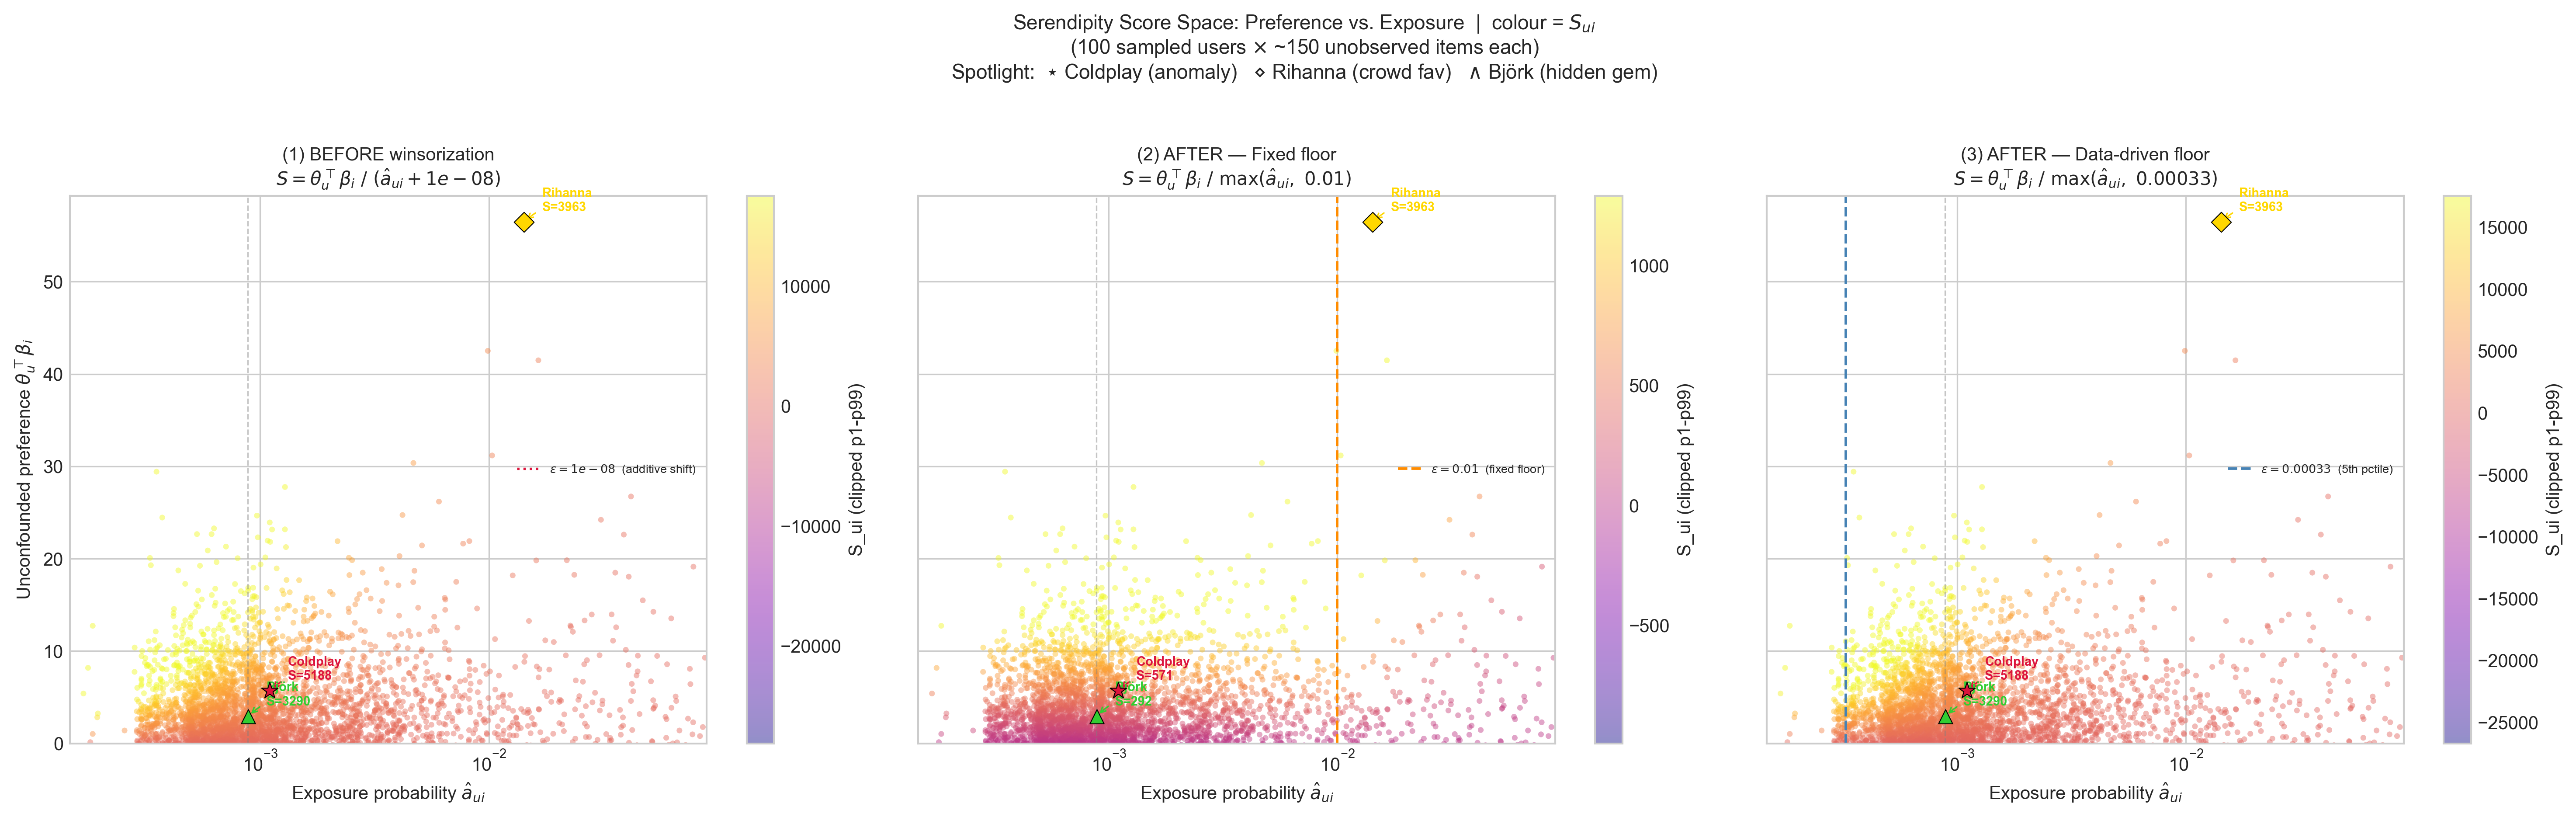


Spotlight artist S_ui comparison:
Artist                 Role           S_ui (original)   S_ui (fixed)  S_ui (dynamic)
------------------------------------------------------------------------------------
Coldplay               anomaly                 5188.0          570.5          5188.1
Rihanna                popular                 3963.3         3963.3          3963.3
Björk                  niche                   3289.6          291.8          3289.6


In [24]:
# Compute axis limits from the actual data rather than hardcoding (use 
# percentiles so a handful of extreme outliers don't force a huge range)
exp_lo = np.percentile(exps_arr[exps_arr > 0], 1) * 0.5
exp_hi = np.percentile(exps_arr, 99) * 1.5
pref_hi = np.percentile(prefs_arr[prefs_arr > 0], 99) * 1.1

# Plot serendipity score space (preference vs. exposure across winsorization 
# situations)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, dpi=300)
scatter_kw = dict(cmap='plasma', s=10, alpha=0.45, linewidths=0, rasterized=True)

# Left: original (additive shift)
sc0 = axes[0].scatter(exps_arr, prefs_arr, c=s_orig_c, **scatter_kw)
axes[0].axvline(EPSILON, color='crimson', linestyle=':', lw=1.3,
                label=f'$\\epsilon = {EPSILON:.0e}$  (additive shift)')
add_median_lines(axes[0], pref_med, exp_med)
overlay_spotlight(axes[0], s_original)
plt.colorbar(sc0, ax=axes[0], label='S_ui (clipped p1-p99)')
axes[0].set_xlabel(r'Exposure probability $\hat{a}_{ui}$', fontsize=10)
axes[0].set_ylabel(r'Unconfounded preference $\theta_u^\top \beta_i$', fontsize=10)
axes[0].set_title(f'(1) BEFORE winsorization\n$S = \\theta_u^\\top \\beta_i \\ / \\ (\\hat{{a}}_{{ui}} + {EPSILON:.0e})$', 
                  fontsize=10)
axes[0].set_xscale('symlog', linthresh=1e-4)
axes[0].legend(fontsize=6.5, loc='center right')

# Middle: fixed floor (WINSORIZE_EPSILON)
sc1 = axes[1].scatter(exps_arr, prefs_arr, c=s_fixed_c, **scatter_kw)
axes[1].axvline(fixed_eps, color='darkorange', linestyle='--', lw=1.4,
                label=f'$\\epsilon = {fixed_eps}$  (fixed floor)')
add_median_lines(axes[1], pref_med, exp_med)
overlay_spotlight(axes[1], s_fixed)
plt.colorbar(sc1, ax=axes[1], label='S_ui (clipped p1-p99)')
axes[1].set_xlabel(r'Exposure probability $\hat{a}_{ui}$', fontsize=10)
axes[1].set_title(f'(2) AFTER — Fixed floor\n$S = \\theta_u^\\top \\beta_i \\ / \\ \\max(\\hat{{a}}_{{ui}},\\ {fixed_eps})$', 
                  fontsize=10)
axes[1].set_xscale('symlog', linthresh=1e-4)
axes[1].legend(fontsize=6.5, loc='center right')

# Right: data-driven floor (5th percentile)
sc2 = axes[2].scatter(exps_arr, prefs_arr, c=s_dyn_c, **scatter_kw)
axes[2].axvline(dynamic_eps, color='steelblue', linestyle='--', lw=1.4,
                label=f'$\\epsilon = {dynamic_eps:.5f}$  (5th pctile)')
add_median_lines(axes[2], pref_med, exp_med)
overlay_spotlight(axes[2], s_dynamic)
plt.colorbar(sc2, ax=axes[2], label='S_ui (clipped p1-p99)')
axes[2].set_xlabel(r'Exposure probability $\hat{a}_{ui}$', fontsize=10)
axes[2].set_title(f'(3) AFTER — Data-driven floor\n$S = \\theta_u^\\top \\beta_i \\ / \\ \\max(\\hat{{a}}_{{ui}},\\ {dynamic_eps:.5f})$', 
                  fontsize=10)
axes[2].set_xscale('symlog', linthresh=1e-4)
axes[2].legend(fontsize=6.5, loc='center right')

rihanna_idx = spotlight_idx['popular']
rihanna_pref = prefs_arr[rihanna_idx] if rihanna_idx is not None else pref_hi
y_top = max(pref_hi, rihanna_pref * 1.05)

for ax in axes:
    ax.set_ylim(bottom=0, top=y_top)
    ax.set_xlim(left=exp_lo, right=exp_hi)

plt.suptitle(
    f'Serendipity Score Space: Preference vs. Exposure  |  colour = $S_{{ui}}$\n'
    f'({SCATTER_USERS} sampled users $\\times$ ~{SCATTER_SAMPLE} unobserved items each)\n'
    r'Spotlight:  $\star$ Coldplay (anomaly)   $\diamond$ Rihanna (crowd fav)   $\wedge$ Björk (hidden gem)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()

# S_ui comparison table
print('\nSpotlight artist S_ui comparison:')
print(f"{'Artist':<22} {'Role':<12} {'S_ui (original)':>17} {'S_ui (fixed)':>14} {'S_ui (dynamic)':>15}")
print('-' * 84)
for role, idx in spotlight_idx.items():
    if idx is None:
        print(f"{SPOTLIGHT[role]:<22} {role:<12} {'(not in sample)':>17}")
        continue
    print(f"{names_list[idx]:<22} {role:<12} "
          f"{s_original[idx]:>17.1f} {s_fixed[idx]:>14.1f} {s_dynamic[idx]:>15.1f}")


In [25]:
# Compute the dynamic epsilon (5th percentile)
dynamic_eps = compute_dynamic_epsilon(a_hat, percentile=5)

# Build slate using fixed epsilon (WINSORIZE_EPSILON) with winsorization enabled
df_fixed = build_serendipity_slate(
    u=TARGET_USER, 
    model=lmf, 
    a_hat=a_hat, 
    A=A, 
    item_to_category=item_to_category, 
    artists=artists, 
    item2idx=item2idx,
    epsilon=WINSORIZE_EPSILON,
    winsorize=True,
    n_slots=10
)

# Build slate using dynamic epsilon (5th percentile) with winsorization enabled
df_dynamic = build_serendipity_slate(
    u=TARGET_USER, 
    model=lmf, 
    a_hat=a_hat, 
    A=A, 
    item_to_category=item_to_category, 
    artists=artists, 
    item2idx=item2idx,
    epsilon=dynamic_eps,
    winsorize=True,
    n_slots=10
)

# Display the DataFrames with styling
print(f"Top 10 Recommendations | Causal + Serendipity (Fixed Floor: {WINSORIZE_EPSILON})")
display(df_fixed.style.format({
    'pref_score': "{:.4f}", 
    'exposure_prob': "{:.6f}", 
    'S_ui': "{:.2f}"
}))

print(f"\nTop 10 Recommendations | Causal + Serendipity (Dynamic Floor: {dynamic_eps:.6f})")
display(df_dynamic.style.format({
    'pref_score': "{:.4f}", 
    'exposure_prob': "{:.6f}", 
    'S_ui': "{:.2f}"
}))

Dynamic epsilon (p5 of non-zero exposures): 0.000326
Top 10 Recommendations | Causal + Serendipity (Fixed Floor: 0.01)


,artist,category,S_ui,pref_score,exposure_prob
rank,,,,,
1,Ke$ha,pop,2386.11,23.8611,0.002455
2,Shakira,pop,2380.44,23.8044,0.006012
3,Michael Jackson,pop,2375.86,23.7586,0.001838
4,Keane,alternative,2185.01,43.9542,0.020116
5,Miley Cyrus,pop,2167.38,21.6738,0.000614
6,Demi Lovato,pop,2137.33,21.3733,0.001244
7,Coldplay,alternative,1969.55,19.6955,0.000395
8,Linkin Park,rock,1946.35,19.4635,0.001674
9,Taylor Swift,other,1895.63,18.9563,0.003939



Top 10 Recommendations | Causal + Serendipity (Dynamic Floor: 0.000326)


,artist,category,S_ui,pref_score,exposure_prob
rank,,,,,
1,Timbaland,other,51802.54,18.5178,0.000357
2,Coldplay,alternative,49824.20,19.6955,0.000395
3,James Morrison,other,40218.52,14.9425,0.000372
4,Nickelback,rock,38619.19,13.7679,0.000357
5,Miley Cyrus,pop,35284.70,21.6738,0.000614
6,Duffy,other,33705.00,13.3236,0.000395
7,Glee Cast,other,30644.57,15.8417,0.000517
8,Depeche Mode,electronic,29393.20,11.6191,0.000395
9,Björk,electronic,28988.70,10.9605,0.000378
